In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [3]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [4]:
question = 'what is happening in Oregon in March 2026?'

answer = ask_api(client, question)
len(answer)

1509

In [5]:
answer[0]

{'claim': 'Dante Moore is lobbying the Oregon governor to support mental health and reveals his own struggles.',
 'url': 'https://nypost.com/2026/03/17/sports/dante-moore-lobbies-oregon-gov-to-support-mental-health-reveals-own-struggles/',
 'domain': 'nypost.com',
 'url_domain': 'nypost.com',
 'date_added': '2026-03-17 04:12:56'}

In [6]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)
df.head()

# ran at 9:14pm > data from 9:12:50 ... nice

,claim,url,domain,url_domain,date_added
0,Dante Moore is lobbying the Oregon governor to...,https://nypost.com/2026/03/17/sports/dante-moo...,nypost.com,nypost.com,2026-03-16 21:12:56-07:00
1,A man died from injuries sustained in a shooti...,https://kptv.com/2026/03/16/man-dies-injuries-...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00
2,A suspect has been arrested after four women w...,https://kptv.com/2026/03/16/suspect-arrested-a...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00
3,Landslides and a sinkhole have triggered road ...,https://kptv.com/2026/03/17/landslides-sinkhol...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00
4,Portland leaders hope for an economic boom dur...,https://kptv.com/video/2026/03/17/portland-lea...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00


In [8]:
df.shape

(1509, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [9]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [10]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [11]:
df.head()

,claim,url,domain,url_domain,date_added
0,Dante Moore is lobbying the Oregon governor to...,https://nypost.com/2026/03/17/sports/dante-moo...,nypost.com,nypost.com,2026-03-16 21:12:56-07:00
1,A man died from injuries sustained in a shooti...,https://kptv.com/2026/03/16/man-dies-injuries-...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00
2,A suspect has been arrested after four women w...,https://kptv.com/2026/03/16/suspect-arrested-a...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00
3,Landslides and a sinkhole have triggered road ...,https://kptv.com/2026/03/17/landslides-sinkhol...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00
4,Portland leaders hope for an economic boom dur...,https://kptv.com/video/2026/03/17/portland-lea...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00


In [37]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.3) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,Dante Moore is lobbying the Oregon governor to...,https://nypost.com/2026/03/17/sports/dante-moo...,nypost.com,nypost.com,2026-03-16 21:12:56-07:00,0
1,A man died from injuries sustained in a shooti...,https://kptv.com/2026/03/16/man-dies-injuries-...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00,1
2,A suspect has been arrested after four women w...,https://kptv.com/2026/03/16/suspect-arrested-a...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00,2
3,Landslides and a sinkhole have triggered road ...,https://kptv.com/2026/03/17/landslides-sinkhol...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00,3
4,Portland leaders hope for an economic boom dur...,https://kptv.com/video/2026/03/17/portland-lea...,kptv.com,kptv.com,2026-03-16 21:12:50-07:00,4


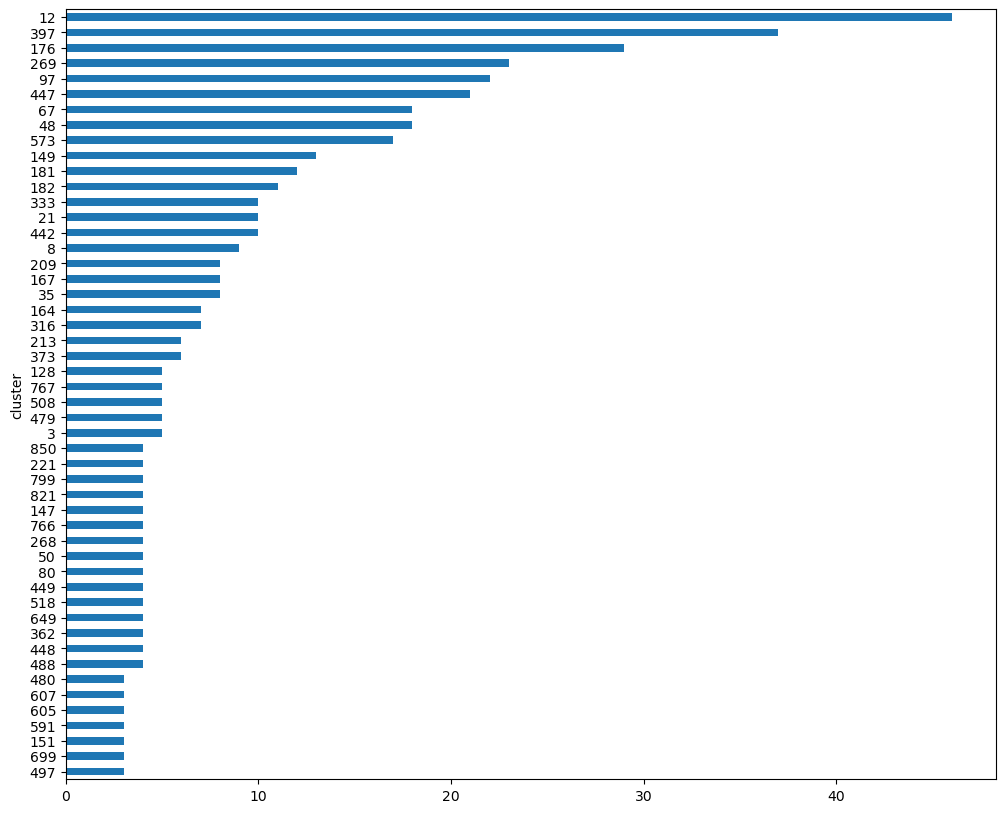

In [38]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [39]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([ 12, 397, 176, 269,  97, 447,  67,  48, 573, 149, 181, 182, 333,
        21, 442,   8, 209, 167,  35, 164, 316, 213, 373, 128, 767, 508,
       479,   3, 850, 221, 799, 821, 147, 766, 268,  50,  80, 449, 518,
       649, 362, 448, 488, 480, 607, 605, 591, 151, 699, 497, 569, 502,
       514, 102, 141, 806, 617,  75, 628, 392, 390, 374, 369, 223, 779,
       236, 241, 351, 692, 283, 284, 698, 537,   5,  73, 472, 451, 180,
       452, 457, 378, 665, 273, 598, 166, 279, 161, 280, 473, 578, 475,
       922,  61, 840, 367,  63, 672, 365, 583, 733, 731, 292, 363,  19,
       608, 262, 811, 237, 233, 777, 230, 413, 918, 416, 418, 401,  43,
       788, 919, 648, 425, 211, 428, 623, 208, 433, 256, 802,  27, 197,
       805, 614, 613,  20, 849, 587, 517,  93, 312, 512, 347, 346, 103,
       101, 343,  99, 520, 554, 553, 549, 115, 548, 887,  88,  87, 323,
       531, 691,  71, 700,  78,  76, 349, 639, 570, 859,  66, 724, 127,
         6, 358, 301, 718, 717, 133, 357, 689, 671, 934, 688, 93

In [41]:
for cluster in top_clusters[0:50]:
    
    print('cluster: {}'.format(cluster))
    
    cluster_data = df[df['cluster']==cluster].head(20)['claim'].values
    print(cluster_data)
    
    print()

cluster: 12
['Tickets are available for the Burly-Q Revue at the Jack London Revue.'
 'An event featuring Davide De Pierro at the Alberta Rose Theatre in Portland, Oregon.'
 'Tickets are available for the BiAmp Portland Jazz Festival.'
 'Tickets are available for the Banff Mountain Film Festival at the McDonald Theatre in Eugene.'
 'Ticket purchase page for Yacht Rock Revue Band at Jack London Revue'
 'Sofia Kourtesis is on tour and tickets are available for the event in Portland.'
 "Tickets are available for Machine Girl's Psychowarrior tour in Portland."
 'Tickets are available for the Portland Trail Blazers game against the Brooklyn Nets.'
 'Tickets are available for the Portland Irish Festival on March 13, 2026.'
 'Tickets for Doug Bundy Duo at the Biamp Portland Jazz Festival on March 12, 2026.'
 'Tickets for Galen Clark Duo at the Biamp Portland Jazz Festival on March 12, 2026.'
 'Tickets for Jack Radsliff Duo at the Biamp Portland Jazz Festival on March 12, 2026.'
 'Tickets for 

In [36]:
# less than five minute OSINT, end at 9:19pm